**Setup**

Datasets: https://www.kaggle.com/datasets/rohitudageri/credit-card-details/

In [1]:
# installing the dependencies
%pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost imblearn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# import the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from joblib import dump

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, average_precision_score, confusion_matrix, roc_auc_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline
from collections import Counter

In [3]:
# configurations
pd.set_option("display.max_columns", None)
sns.set_theme(style="darkgrid")

RANDOM_STATE = 42

**Load Datasets**

In [4]:
# read csv file into a pandas dataframe
df = pd.read_csv("D:\My Learning\ML projects\Credit-Card-Approval-Prediction\datasets\Credit_card.csv")
target = pd.read_csv("D:\My Learning\ML projects\Credit-Card-Approval-Prediction\datasets\Credit_card_label.csv")

**About the Datasets**

*Features name: (Credit_Card.csv)*

Ind_ID: Client ID

Gender: Gender information

Car_owner: Having car or not

Propert_owner: Having property or not

Children: Count of children

Annual_income: Annual income

Type_Income: Income type

Education: Education level

Marital_status: Marital_status

Housing_type: Living style

Birthday_count: Use backward count from current day (0), -1 means yesterday.

Employed_days: Start date of employment. Use backward count from current day (0). Positive value means, individual is currently unemployed.

Mobile_phone: Any mobile phone

Work_phone: Any work phone

Phone: Any phone number

EMAIL_ID: Any email ID

Type_Occupation: Occupation

Family_Members: Family size

*Another data set (Credit_card_label.csv) contains two key pieces of information*

ID: The joining key between application data and credit status data, same is Ind_ID

Label: 0 is application approved and 1 is application rejected.

**EDA**

In [5]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2


In [6]:
target.head()

,Ind_ID,label
0,5008827,1
1,5009744,1
2,5009746,1
3,5009749,1
4,5009752,1


In [7]:
df.shape

(1548, 18)

In [8]:
target.shape

(1548, 2)

In [9]:
# missing values - analysis
df.isnull().sum()

Ind_ID               0
GENDER               7
Car_Owner            0
Propert_Owner        0
CHILDREN             0
Annual_income       23
Type_Income          0
EDUCATION            0
Marital_status       0
Housing_type         0
Birthday_count      22
Employed_days        0
Mobile_phone         0
Work_Phone           0
Phone                0
EMAIL_ID             0
Type_Occupation    488
Family_Members       0
dtype: int64

In [10]:
# missing values - analysis
target.isnull().sum()

Ind_ID    0
label     0
dtype: int64

In [11]:
# identify the presence of encoded missing values
for col in df.columns:
    print(df[col].value_counts())

Ind_ID
5008827    1
5009744    1
5009746    1
5009749    1
5009752    1
          ..
5028645    1
5023655    1
5115992    1
5118219    1
5053790    1
Name: count, Length: 1548, dtype: int64
GENDER
F    973
M    568
Name: count, dtype: int64
Car_Owner
N    924
Y    624
Name: count, dtype: int64
Propert_Owner
Y    1010
N     538
Name: count, dtype: int64
CHILDREN
0     1091
1      305
2      134
3       16
4        1
14       1
Name: count, dtype: int64
Annual_income
135000.0    170
112500.0    144
180000.0    137
157500.0    125
225000.0    119
           ... 
165600.0      1
114750.0      1
47250.0       1
49500.0       1
69750.0       1
Name: count, Length: 115, dtype: int64
Type_Income
Working                 798
Commercial associate    365
Pensioner               269
State servant           116
Name: count, dtype: int64
EDUCATION
Secondary / secondary special    1031
Higher education                  426
Incomplete higher                  68
Lower secondary                    21
Aca

In [12]:
# identify the presence of encoded missing values
for col in target.columns:
    print(target[col].value_counts())

Ind_ID
5008827    1
5009744    1
5009746    1
5009749    1
5009752    1
          ..
5028645    1
5023655    1
5115992    1
5118219    1
5053790    1
Name: count, Length: 1548, dtype: int64
label
0    1373
1     175
Name: count, dtype: int64


In [13]:
# join both datafames using inner join
df = pd.merge(df, target, on='Ind_ID', how='inner')

In [14]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df = df.drop(columns=["Ind_ID"])

In [17]:
# identify duplicate rows
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()

print("Number of duplicate rows:", num_duplicates)
print("Duplicated row:\n",df[duplicate_mask])


Number of duplicate rows: 162
Duplicated row:
      GENDER Car_Owner Propert_Owner  CHILDREN  Annual_income  \
4         F         Y             N         0       315000.0   
6         F         Y             N         0       315000.0   
13        F         Y             Y         0        90000.0   
18        F         N             Y         0       126000.0   
42        F         N             Y         0       225000.0   
...     ...       ...           ...       ...            ...   
1517      F         N             Y         0       112500.0   
1520      M         N             Y         0       157500.0   
1522      M         N             Y         1       135000.0   
1527      F         Y             N         0       126000.0   
1545      M         Y             Y         2       180000.0   

               Type_Income                      EDUCATION  \
4     Commercial associate               Higher education   
6     Commercial associate               Higher education   
1

In [18]:
df = df.drop_duplicates()
df.shape

(1386, 18)

In [19]:
# class distribution
print(df["label"].value_counts())
print("-"*50)
print(df["label"].value_counts(normalize=True)*100)

label
0    1249
1     137
Name: count, dtype: int64
--------------------------------------------------
label
0    90.11544
1     9.88456
Name: proportion, dtype: float64


In [20]:
# Check constant columns
df.nunique()

GENDER                2
Car_Owner             2
Propert_Owner         2
CHILDREN              6
Annual_income       115
Type_Income           4
EDUCATION             5
Marital_status        5
Housing_type          6
Birthday_count     1270
Employed_days       956
Mobile_phone          1
Work_Phone            2
Phone                 2
EMAIL_ID              2
Type_Occupation      18
Family_Members        7
label                 2
dtype: int64

In [21]:
# Dropping constant column
df = df.drop(columns=["Mobile_phone"])

In [22]:
# Convert Birthday_count to age
df['Age'] = (-df['Birthday_count'] / 365.25).round(1)
df.drop('Birthday_count', axis=1, inplace=True)

In [23]:
df["Age"].dtype

dtype('float64')

In [24]:
df["Age"].isnull().sum()

np.int64(22)


Fill missing numerical values with the middle value (median) age, which is better if our data has extreme outliers

In [25]:
# Fill empty age cells with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# For data with NO missing values
df['Age'] = df['Age'].astype(int)

In [26]:
# 365243 value means, individual is currently unemployed.
df['Is_Unemployed'] = (df['Employed_days'] == 365243).astype(int)

In [27]:
df.head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Employed_days,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label,Age,Is_Unemployed
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,365243,0,0,0,NaN,2,1,51,1
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-586,1,1,0,NaN,2,1,37,0
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-586,1,1,0,NaN,2,1,42,0
3,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-586,1,1,0,NaN,2,1,37,0
5,NaN,Y,N,0,315000.0,Pensioner,Higher education,Married,House / apartment,-586,1,1,0,NaN,2,1,37,0


In [28]:
# Convert employed days to actual number of days
from numpy import floor


df['Employment_days'] = df['Employed_days'].abs()

# 365243 is a special value representing unemployment
df.loc[df['Employed_days'] == 365243, 'Employment_days'] = 0

df['Employment_years'] = floor(df['Employment_days'] / 365.25)
df['Employment_years'] = df['Employment_years'].astype(int)
df.drop('Employed_days', axis=1, inplace=True)
df.drop('Is_Unemployed', axis=1, inplace=True)
df.drop('Employment_days', axis=1, inplace=True)


In [29]:
df.head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label,Age,Employment_years
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,0,0,0,NaN,2,1,51,0
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,NaN,2,1,37,1
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,NaN,2,1,42,1
3,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,1,1,0,NaN,2,1,37,1
5,NaN,Y,N,0,315000.0,Pensioner,Higher education,Married,House / apartment,1,1,0,NaN,2,1,37,1


In [30]:
# fill the missing values in GENDER Col with the mode
df['GENDER'] = df['GENDER'].fillna(df['GENDER'].mode()[0])

In [31]:
# missing values - analysis
df.isnull().sum()

GENDER                0
Car_Owner             0
Propert_Owner         0
CHILDREN              0
Annual_income        23
Type_Income           0
EDUCATION             0
Marital_status        0
Housing_type          0
Work_Phone            0
Phone                 0
EMAIL_ID              0
Type_Occupation     438
Family_Members        0
label                 0
Age                   0
Employment_years      0
dtype: int64

In [32]:
# Fill missing values in Annual_income
df['Annual_income'] = df['Annual_income'].fillna(df['Annual_income'].median())

# fill missing values in Type_Occupation
df['Type_Occupation'] = df['Type_Occupation'].fillna('Others')

In [33]:
df.isnull().sum()


GENDER              0
Car_Owner           0
Propert_Owner       0
CHILDREN            0
Annual_income       0
Type_Income         0
EDUCATION           0
Marital_status      0
Housing_type        0
Work_Phone          0
Phone               0
EMAIL_ID            0
Type_Occupation     0
Family_Members      0
label               0
Age                 0
Employment_years    0
dtype: int64

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1386 entries, 0 to 1547
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   GENDER            1386 non-null   object 
 1   Car_Owner         1386 non-null   object 
 2   Propert_Owner     1386 non-null   object 
 3   CHILDREN          1386 non-null   int64  
 4   Annual_income     1386 non-null   float64
 5   Type_Income       1386 non-null   object 
 6   EDUCATION         1386 non-null   object 
 7   Marital_status    1386 non-null   object 
 8   Housing_type      1386 non-null   object 
 9   Work_Phone        1386 non-null   int64  
 10  Phone             1386 non-null   int64  
 11  EMAIL_ID          1386 non-null   int64  
 12  Type_Occupation   1386 non-null   object 
 13  Family_Members    1386 non-null   int64  
 14  label             1386 non-null   int64  
 15  Age               1386 non-null   int64  
 16  Employment_years  1386 non-null   int64  
dtype

**Data Visualization**

In [35]:
df["label"].value_counts()

label
0    1249
1     137
Name: count, dtype: int64

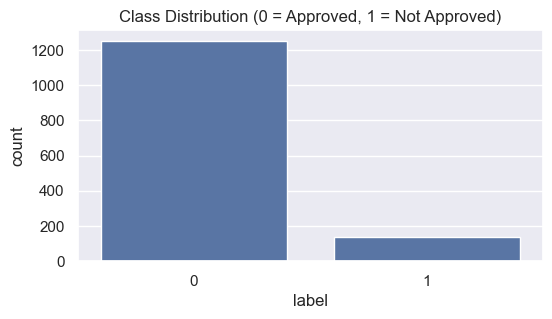

In [36]:
plt.figure(figsize=(6,3))
sns.countplot(x="label", data=df)
plt.title("Class Distribution (0 = Approved, 1 = Not Approved)")
plt.show()

In [37]:
df.head()

,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label,Age,Employment_years
0,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,0,0,0,Others,2,1,51,0
1,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,Others,2,1,37,1
2,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,Others,2,1,42,1
3,F,Y,N,0,162000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,Others,2,1,37,1
5,F,Y,N,0,315000.0,Pensioner,Higher education,Married,House / apartment,1,1,0,Others,2,1,37,1


In [38]:
numerical_cols = ["CHILDREN","Annual_income","Family_Members","Age","Employment_years"]

categorical_cols = ["GENDER", "Car_Owner", "Propert_Owner","Type_Income","Type_Occupation","EDUCATION","Marital_status","Housing_type","Work_Phone",
                    "Phone", "EMAIL_ID", "label"]


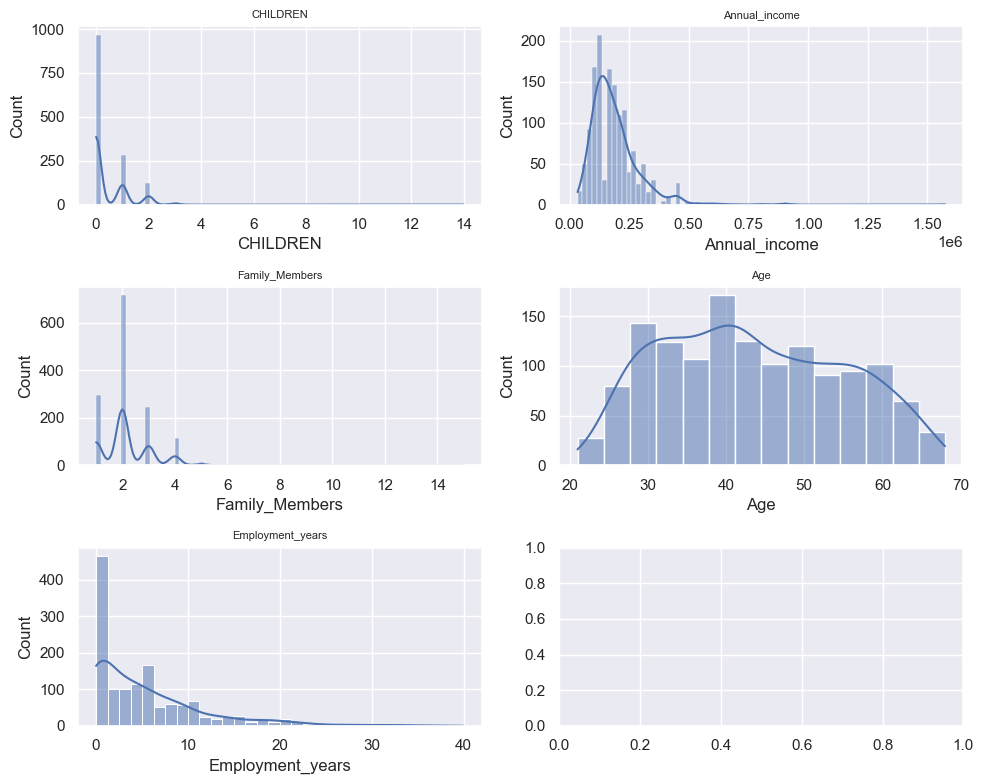

In [39]:
# histogram plot - distribution - for numerical features
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

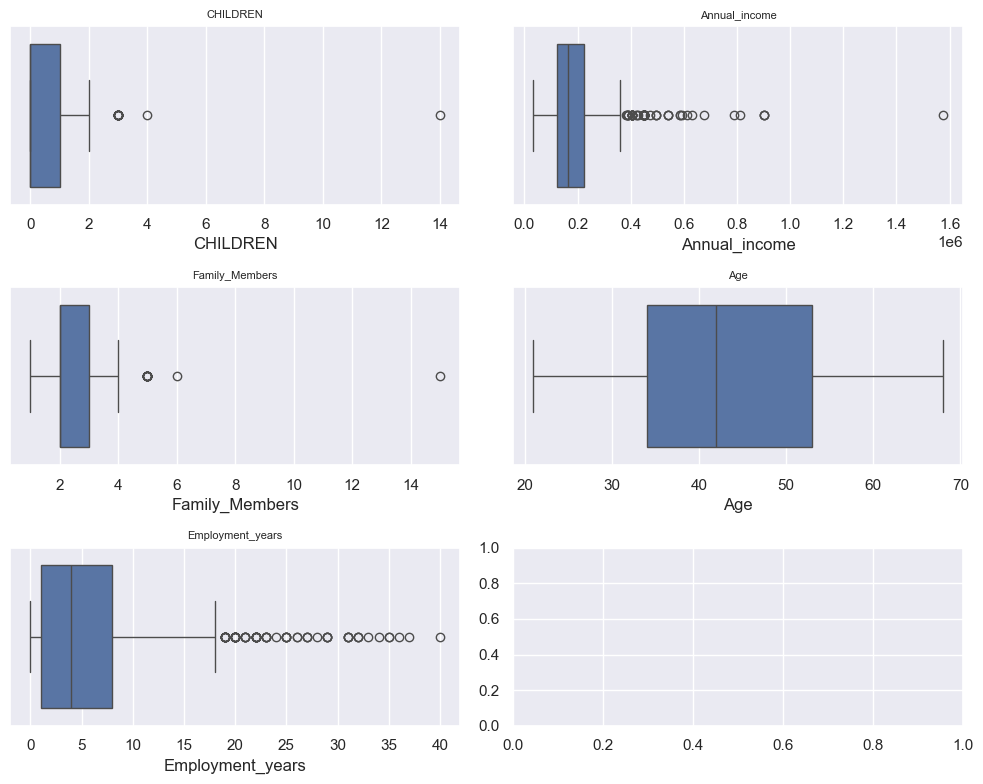

In [40]:
# outliers analysis - boxplot
fig, axes = plt.subplots(3, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

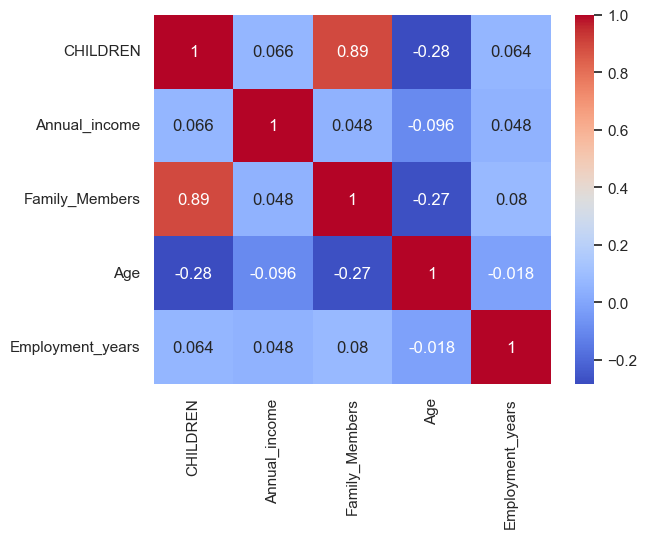

In [41]:
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [42]:
# highly corrleated features
df[['CHILDREN', 'Family_Members']].corr()

,CHILDREN,Family_Members
CHILDREN,1.000000,0.893873
Family_Members,0.893873,1.000000


Check which variable has more useful information for predicting your target.

In [43]:
df.groupby('CHILDREN')['label'].mean()

CHILDREN
0     0.099276
1     0.107143
2     0.082645
3     0.000000
4     1.000000
14    0.000000
Name: label, dtype: float64

In [44]:
df.groupby('Family_Members')['label'].mean()

Family_Members
1     0.102041
2     0.103641
3     0.093496
4     0.078261
5     0.000000
6     1.000000
15    0.000000
Name: label, dtype: float64

In [45]:
print(df.groupby('CHILDREN')['label'].agg(['count', 'mean']))
print(df.groupby('Family_Members')['label'].agg(['count', 'mean']))

          count      mean
CHILDREN                 
0           967  0.099276
1           280  0.107143
2           121  0.082645
3            16  0.000000
4             1  1.000000
14            1  0.000000
                count      mean
Family_Members                 
1                 294  0.102041
2                 714  0.103641
3                 246  0.093496
4                 115  0.078261
5                  15  0.000000
6                   1  1.000000
15                  1  0.000000


In [46]:
# Family_members has a more meaningful distribution
df = df.drop(columns=['CHILDREN'])
numerical_cols.remove("CHILDREN")

In [47]:
df.nunique()

GENDER                2
Car_Owner             2
Propert_Owner         2
Annual_income       115
Type_Income           4
EDUCATION             5
Marital_status        5
Housing_type          6
Work_Phone            2
Phone                 2
EMAIL_ID              2
Type_Occupation      19
Family_Members        7
label                 2
Age                  48
Employment_years     38
dtype: int64

In [48]:
# missing values - analysis
df.isnull().sum()

GENDER              0
Car_Owner           0
Propert_Owner       0
Annual_income       0
Type_Income         0
EDUCATION           0
Marital_status      0
Housing_type        0
Work_Phone          0
Phone               0
EMAIL_ID            0
Type_Occupation     0
Family_Members      0
label               0
Age                 0
Employment_years    0
dtype: int64

**Data Preprocessing**

In [49]:
X = df.drop('label', axis=1)
y = df['label']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [51]:
print("Train shape:", X_train.shape)

print("Test shape:", X_test.shape)

Train shape: (1108, 15)
Test shape: (278, 15)


In [52]:
df.head()

,GENDER,Car_Owner,Propert_Owner,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label,Age,Employment_years
0,M,Y,Y,180000.0,Pensioner,Higher education,Married,House / apartment,0,0,0,Others,2,1,51,0
1,F,Y,N,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,Others,2,1,37,1
2,F,Y,N,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,Others,2,1,42,1
3,F,Y,N,162000.0,Commercial associate,Higher education,Married,House / apartment,1,1,0,Others,2,1,37,1
5,F,Y,N,315000.0,Pensioner,Higher education,Married,House / apartment,1,1,0,Others,2,1,37,1


In [53]:
numerical_features = numerical_cols
categorical_features = categorical_cols
categorical_features.remove("label")

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['Annual_income', 'Family_Members', 'Age', 'Employment_years']
Categorical features: ['GENDER', 'Car_Owner', 'Propert_Owner', 'Type_Income', 'Type_Occupation', 'EDUCATION', 'Marital_status', 'Housing_type', 'Work_Phone', 'Phone', 'EMAIL_ID']


cat__Housing_type        0.102627
num__Employment_years    0.095468
num__Family_Members      0.092969
cat__Marital_status      0.091093
cat__Type_Occupation     0.090646
cat__Type_Income         0.086501
cat__EDUCATION           0.086213
num__Age                 0.084255
num__Annual_income       0.077139
cat__GENDER              0.066200
cat__Car_Owner           0.065275
cat__Propert_Owner       0.061614
dtype: float32

In [54]:
# numerical features - preprocessing steps
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps=[
        ("ordinal", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
        ))
    ]
)

# preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Baseline Model (No CV, No Tuning)

In [55]:
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [56]:
# preprocess the data and train the baseline model
baseline_pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given 

Evaluation of baseline model

In [57]:
test_baseline_pred = baseline_pipe.predict(X_test)

In [58]:
print(confusion_matrix(y_test,test_baseline_pred))
print(classification_report(y_test, test_baseline_pred))

[[153  98]
 [ 11  16]]
              precision    recall  f1-score   support

           0       0.93      0.61      0.74       251
           1       0.14      0.59      0.23        27

    accuracy                           0.61       278
   macro avg       0.54      0.60      0.48       278
weighted avg       0.86      0.61      0.69       278



In [59]:
base_test_acc = round(accuracy_score(y_test, test_baseline_pred)*100, 2)
print("Baseline Test Accuracy:", base_test_acc)

Baseline Test Accuracy: 60.79


Note: Accuracy score is not reliable because of class imbalance

In [60]:
# average precision score (or) pr-auc - test data
y_test_prob = baseline_pipe.predict_proba(X_test)[:, 1]
print("Test Average Precision Score:", average_precision_score(y_test, y_test_prob))

Test Average Precision Score: 0.14368997719687643


In [61]:
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))
print("PR-AUC:", average_precision_score(y_test, y_test_prob))

ROC-AUC: 0.5852146967684816
PR-AUC: 0.14368997719687643


Model Selection & Optimization

In [62]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [63]:
from sklearn.tree import DecisionTreeClassifier
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    )   
}

In [64]:
scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [65]:
rows = []

for name, model in models.items():

    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=skf,
        scoring=scoring
    )

    rows.append({
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "precision_macro": scores["test_precision_macro"].mean(),
        "recall_macro": scores["test_recall_macro"].mean(),
        "f1_macro": scores["test_f1_macro"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
        "pr_auc": scores["test_pr_auc"].mean()
    })

results_df = pd.DataFrame(rows)

c:\Users\Abhishek Negi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [66]:
results_df

,model,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,pr_auc
0,Logistic Regression,0.581269,0.520939,0.557237,0.457654,0.593461,0.157805
1,Random Forest,0.904341,0.733120,0.530316,0.529712,0.628577,0.263607
2,XGBoost,0.893522,0.650185,0.560707,0.576271,0.640613,0.247126
3,Decision Tree,0.842974,0.584013,0.597357,0.589254,0.597767,0.149857


Accuracy is misleading for imbalanced dataset. XGBoost is the preferred candidate for further hyperparameter tuning and class-imbalance experimentation.

**Hyperparameter Tuning**


1. for XGBoost

**WITHOUT SMONEC**

In [67]:
counter = Counter(y_train)

scale_pos_weight = counter[0] / counter[1]

xgb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", XGBClassifier(
            objective="binary:logistic",
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

# model__ prefix is only used when specifying parameters for RandomizedSearchCV/GridSearchCV on a pipeline.
param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.2]
}

search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=param_grid,
    n_iter=50,
    scoring="f1_macro",
    cv=skf,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 0.9, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strat

In [68]:
print("Best Parameters:")
print(search.best_params_)

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'model__gamma': 0.1, 'model__colsample_bytree': 0.8}


In [69]:
xgb_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=1,
            gamma=0.1,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            scale_pos_weight=scale_pos_weight
        ))
    ]
)
xgb_best.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given 

In [70]:
# xgb_model = xgb_best.named_steps["model"]
# preprocessor = xgb_best.named_steps["preprocess"]

# feature_names = preprocessor.get_feature_names_out()

# importance = pd.Series(
#     xgb_model.feature_importances_,
#     index=feature_names
# ).sort_values(ascending=False)

# print(importance)
# print(importance.tail(10))

In [71]:
y_train_prob = xgb_best.predict_proba(X_train)[:, 1]

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.10, 0.91, 0.01):
    y_pred = (y_train_prob >= threshold).astype(int)
    f1 = f1_score(y_train, y_pred, pos_label=1)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

# print("Best threshold:", best_threshold)
# print("Best class 1 F1:", best_f1)

y_pred_best = (y_train_prob >= best_threshold).astype(int)

print("Training prediction")
print(classification_report(y_train, y_pred_best))

Training prediction
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       998
           1       0.95      1.00      0.97       110

    accuracy                           0.99      1108
   macro avg       0.97      1.00      0.99      1108
weighted avg       0.99      0.99      0.99      1108



In [72]:
y_test_prob = xgb_best.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.10, 0.91, 0.01):
    y_pred = (y_test_prob >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred, pos_label=1)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

# print("Best threshold:", best_threshold)
# print("Best class 1 F1:", best_f1)

y_pred_best = (y_test_prob >= best_threshold).astype(int)

print("Testing prediction")

print(classification_report(y_test, y_pred_best))

Testing prediction
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       251
           1       0.48      0.44      0.46        27

    accuracy                           0.90       278
   macro avg       0.71      0.70      0.70       278
weighted avg       0.90      0.90      0.90       278



In [75]:
dump(xgb_best, "D:/My Learning/ML projects/Credit-Card-Approval-Prediction/backend/xgb_best.joblib")

['D:/My Learning/ML projects/Credit-Card-Approval-Prediction/backend/xgb_best.joblib']

**WITH SMOTENC**

In [74]:
# categorical_indices = list(
#     range(
#         len(numerical_features),
#         len(numerical_features) + len(categorical_features)
#     )
# )

# # print(categorical_indices)
# smotenc = SMOTENC(
#     categorical_features=categorical_indices,
#     random_state=42
# )

# xgb_pipe = Pipeline(
#     steps=[
#         ("preprocess", preprocess),
#         ("smotenc", smotenc),
#         ("model", XGBClassifier(
#             objective="binary:logistic",
#             scale_pos_weight=1,
#             eval_metric="logloss",
#             random_state=42
#         ))
#     ]
# )

# # model__ prefix is only used when specifying parameters for RandomizedSearchCV/GridSearchCV on a pipeline.
# param_grid = {
#     "model__n_estimators": [100, 200, 300, 500],
#     "model__max_depth": [3, 4, 5, 6],
#     "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
#     "model__subsample": [0.8, 0.9, 1.0],
#     "model__colsample_bytree": [0.8, 0.9, 1.0],
#     "model__min_child_weight": [1, 3, 5],
#     "model__gamma": [0, 0.1, 0.2]
# }

# search = RandomizedSearchCV(
#     estimator=xgb_pipe,
#     param_distributions=param_grid,
#     n_iter=50,
#     scoring="f1_macro",
#     cv=skf,
#     random_state=42,
#     n_jobs=-1,
#     verbose=1
# )

# search.fit(X_train, y_train)

# y_prob = search.predict_proba(X_test)[:, 1]

# best_threshold = 0.5
# best_f1 = 0

# for threshold in np.arange(0.10, 0.91, 0.01):
#     y_pred = (y_prob >= threshold).astype(int)
#     f1 = f1_score(y_test, y_pred, pos_label=1)

#     if f1 > best_f1:
#         best_f1 = f1
#         best_threshold = threshold

# print("Best threshold:", best_threshold)
# print("Best class 1 F1:", best_f1)

# y_pred_best = (y_prob >= best_threshold).astype(int)

# print(classification_report(y_test, y_pred_best))